# **Product Analytics: User Funnel & Conversion Optimization**

This project analyzes user behavior from event-level data to identify drop-offs, optimize conversion rates, and generate actionable business insights.

In [61]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

**Data Loading**

In [62]:
# Upload dataset (only needed in Colab)
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [65]:

df = pd.read_csv('events_sample.csv')

# Quick overview
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-09 02:46:19 UTC,view,29900078,2059484601444729123,NaN,peda,1647.40,532353313,47059489-3a63-4353-9eab-0e239d5cb5aa
1,2019-10-21 16:17:11 UTC,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e
2,2019-10-21 14:42:20 UTC,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3
3,2019-10-03 18:40:22 UTC,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c
4,2019-10-19 08:58:51 UTC,view,5300097,2053013563173241677,NaN,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b


**Pipeline**

**Step 1 — Data Understanding**

In [73]:
#1  Inspect the Dataset

# Shows data types and non-null counts
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     400000 non-null  object 
 1   event_type     400000 non-null  object 
 2   product_id     400000 non-null  int64  
 3   category_id    400000 non-null  int64  
 4   category_code  272769 non-null  object 
 5   brand          342183 non-null  object 
 6   price          400000 non-null  float64
 7   user_id        400000 non-null  int64  
 8   user_session   400000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 27.5+ MB


Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [74]:
#2 Explore Event Types

df['event_type'].value_counts()

,count
event_type,
view,384192
cart,8665
purchase,7143


In [75]:
#3 Unique Users

df['user_id'].nunique()

305791

**Step 2 — Data Preprocessing**

In [76]:
#1 Convert Time Column to Datetime

df['event_time'] = pd.to_datetime(df['event_time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     400000 non-null  datetime64[ns, UTC]
 1   event_type     400000 non-null  object             
 2   product_id     400000 non-null  int64              
 3   category_id    400000 non-null  int64              
 4   category_code  272769 non-null  object             
 5   brand          342183 non-null  object             
 6   price          400000 non-null  float64            
 7   user_id        400000 non-null  int64              
 8   user_session   400000 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 27.5+ MB


**Step 3 — Funnel Analysis**

In [77]:
#1 Funnel

views = df[df['event_type']=='view']['user_id'].nunique()
carts = df[df['event_type']=='cart']['user_id'].nunique()
purchases = df[df['event_type']=='purchase']['user_id'].nunique()

cart_rate = carts / views
purchase_rate = purchases / views

# NEW METRIC (IMPORTANT)
conversion_drop = (1 - purchase_rate) * 100

# CLEAN SUMMARY TABLE
funnel_summary = pd.DataFrame({
    'Metric': ['Views', 'Carts', 'Purchases', 'Cart Rate', 'Purchase Rate', 'Drop-off %'],
    'Value': [views, carts, purchases, cart_rate, purchase_rate, conversion_drop]
})

# Funnel Visualizationfunnel_summary

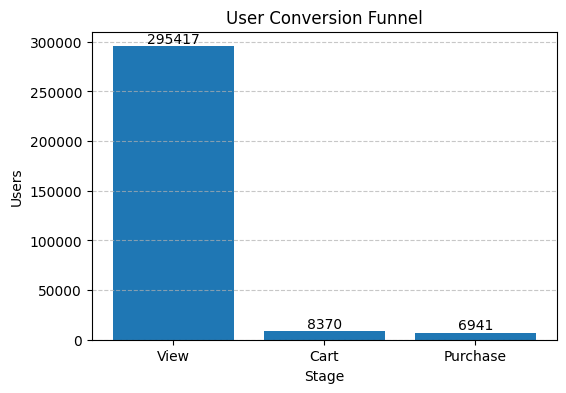

In [78]:
#2 Funnel Visualization

stages = ['View','Cart','Purchase']
values = [views,carts,purchases]

plt.figure(figsize=(6,4))

plt.bar(stages,values)

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.title("User Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Step 4 — Revenue Analysis**

In [79]:
#1 Category Revenue Analysis

purchases_df = df[df['event_type']=='purchase']

category_revenue = purchases_df.groupby('category_code')['price'].sum().sort_values(ascending=False)

category_revenue.head(10)

,price
category_code,
electronics.smartphone,1481702.04
computers.notebook,77974.92
electronics.video.tv,77487.87
electronics.clocks,51979.77
appliances.kitchen.refrigerators,39927.97
appliances.kitchen.washer,39310.56
electronics.audio.headphone,29732.48
appliances.environment.vacuum,17820.14
computers.desktop,14783.40


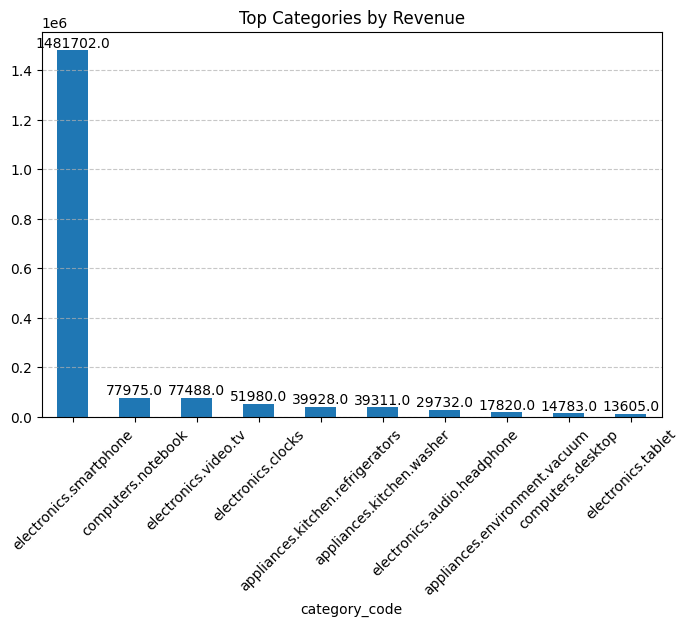

In [80]:
#2 Category Revenue Visualization

category_revenue.head(10).plot(kind='bar',figsize=(8,5))

plt.title("Top Categories by Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for i, v in enumerate(category_revenue.head(10)):
    plt.text(i, v, str(round(v,0)), ha='center', va='bottom')

plt.show()

**Step 5 — Time Analysis**

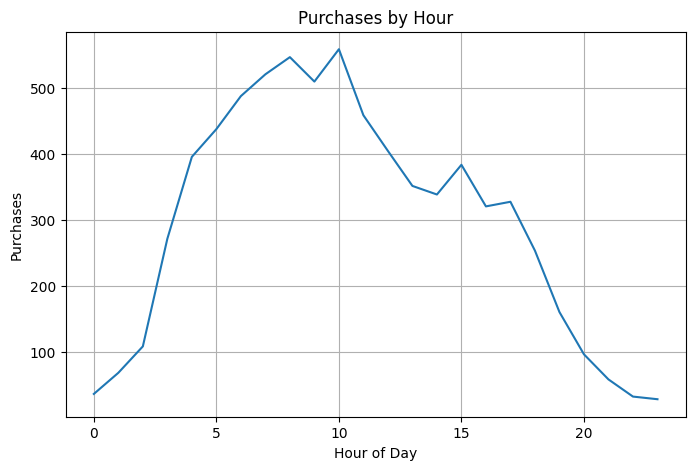

In [81]:
df['hour'] = df['event_time'].dt.hour
hourly_purchases = df[df['event_type']=='purchase'].groupby('hour').size()

hourly_purchases.plot(kind='line',figsize=(8,5))
plt.title("Purchases by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Purchases")
plt.grid(True)
plt.show()

**Step 6 — Product Analysis**

In [82]:
top_products = purchases_df.groupby('product_id')['price'].sum().sort_values(ascending=False)

top_products.head(10)

,price
product_id,
1005115,114832.65
1005105,85696.17
1004249,75465.25
1005135,55275.33
1004767,53966.71
1002544,43284.50
1004856,36899.53
1002524,34317.67
1003317,30208.04


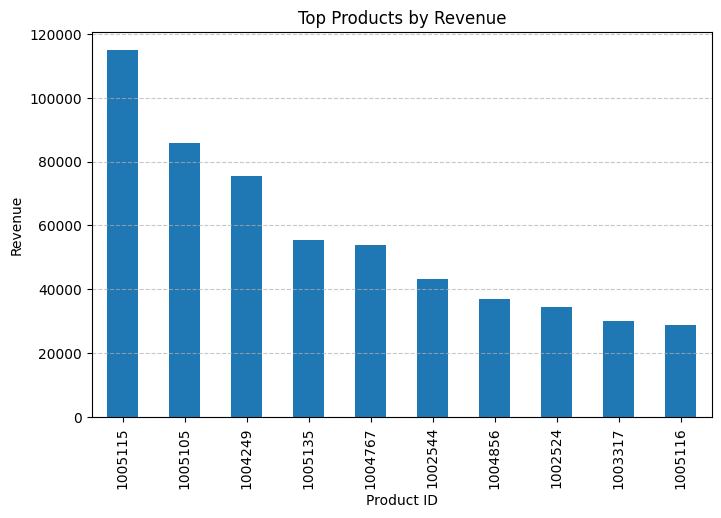

In [83]:
top_products.head(10).plot(kind='bar',figsize=(8,5))

plt.title("Top Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Revenue")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Step 7 — Data Export**

In [84]:
funnel_df = pd.DataFrame({
    'stage': ['View', 'Cart', 'Purchase'],
    'users': [views, carts, purchases]
})

category_revenue.to_csv('category_revenue.csv')
hourly_purchases.to_csv('hourly_purchases.csv')
funnel_df.to_csv('funnel_data.csv', index=False)

**Key Insights**

- Only ~2–3% of users convert to purchase
- Major drop-off occurs between View → Cart stage
- Smartphones generate the highest revenue
- Peak purchases occur between 6 PM – 10 PM
- ~97% users drop before purchase

**Business Recommendations**

- Improve product page UX to reduce drop-off
- Optimize checkout process
- Focus marketing on high-performing categories
- Run campaigns during peak hours

**Conclusion**

This analysis identifies key bottlenecks in the conversion funnel and provides actionable insights to improve user engagement, conversion rates, and revenue performance.